In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [71]:
df = pd.read_csv("D:/Project - 2025/Funnel/funnel_analysis_data.csv")

df

,user_id,session_id,Event,Timestamp,Device,Region,Channel,product_category,Revenue,bounce_flag
0,USR00001,SES00001,Browser,21-03-2026 16:38,Desktop,North,Organic,Grocery,0.0,yes
1,USR00001,SES00001,Product View,21-03-2026 16:42,Mobile,West,Referral,Home & Garden,0.0,yes
2,USR00001,SES00001,Add to Cart,21-03-2026 16:44,Mobile,East,Twitter Ads,Clothing,0.0,yes
3,USR00002,SES00002,Browser,17-03-2026 08:11,Tablet,West,Social Media,Office Supplies,0.0,yes
4,USR00003,SES00003,Browser,29-03-2026 12:47,Tablet,East,Social Media,Health & Beauty,0.0,yes
...,...,...,...,...,...,...,...,...,...,...
27254,USR09998,SES09998,Browser,14-03-2026 09:07,Desktop,Central,Paid,Automotive,0.0,yes
27255,USR09998,SES09998,Product View,14-03-2026 09:10,Tablet,South,Facebook Ads,Home & Garden,0.0,yes
27256,USR09999,SES09999,Browser,08-03-2026 01:44,Desktop,Central,Social Media,Home & Garden,0.0,yes
27257,USR10000,SES10000,Browser,27-02-2026 14:01,Mobile,North,Organic,Books,0.0,yes


In [75]:
print(df.head())

    user_id session_id         Event         Timestamp   Device Region  \
0  USR00001   SES00001       Browser  21-03-2026 16:38  Desktop  North   
1  USR00001   SES00001  Product View  21-03-2026 16:42   Mobile   West   
2  USR00001   SES00001   Add to Cart  21-03-2026 16:44   Mobile   East   
3  USR00002   SES00002       Browser  17-03-2026 08:11   Tablet   West   
4  USR00003   SES00003       Browser  29-03-2026 12:47   Tablet   East   

        Channel product_category  Revenue bounce_flag  
0       Organic          Grocery      0.0         yes  
1      Referral    Home & Garden      0.0         yes  
2   Twitter Ads         Clothing      0.0         yes  
3  Social Media  Office Supplies      0.0         yes  
4  Social Media  Health & Beauty      0.0         yes  


In [77]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27259 entries, 0 to 27258
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           27259 non-null  object 
 1   session_id        27259 non-null  object 
 2   Event             27259 non-null  object 
 3   Timestamp         27259 non-null  object 
 4   Device            27259 non-null  object 
 5   Region            27259 non-null  object 
 6   Channel           27259 non-null  object 
 7   product_category  27259 non-null  object 
 8   Revenue           27259 non-null  float64
 9   bounce_flag       27259 non-null  object 
dtypes: float64(1), object(9)
memory usage: 2.1+ MB
None


In [79]:
print(df['Event'].value_counts())

Event
Browser         10000
Product View     7957
Add to Cart      5657
Checkout         2792
Purchase          853
Name: count, dtype: int64


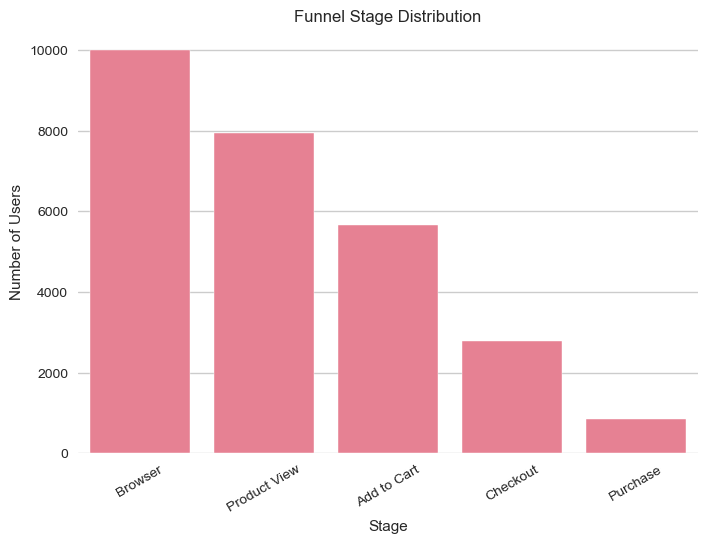

In [81]:
stage_counts = df['Event'].value_counts().reindex(
    ['Browser', 'Product View', 'Add to Cart', 'Checkout', 'Purchase']
)

plt.figure()
sns.barplot(x=stage_counts.index, y=stage_counts.values)

plt.title("Funnel Stage Distribution")
plt.xlabel("Stage")
plt.ylabel("Number of Users")
plt.xticks(rotation=30)

plt.show()

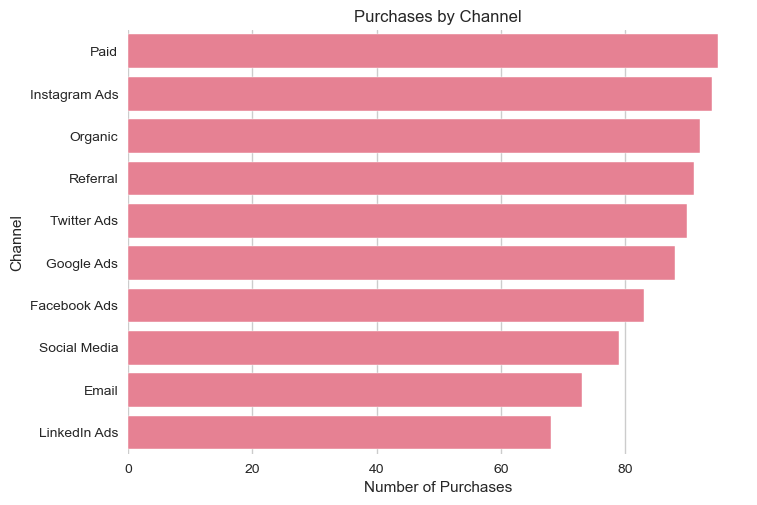

In [83]:
conversion = df[df['Event'] == 'Purchase'].groupby('Channel').size().sort_values(ascending=False)

plt.figure()
sns.barplot(x=conversion.values, y=conversion.index)

plt.title("Purchases by Channel")
plt.xlabel("Number of Purchases")
plt.ylabel("Channel")

plt.show()

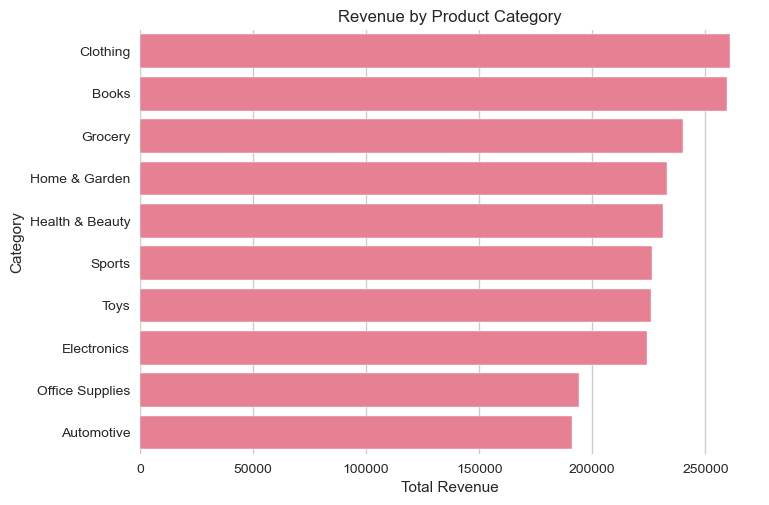

In [85]:
revenue_cat = df.groupby('product_category')['Revenue'].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=revenue_cat.values, y=revenue_cat.index)

plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")

plt.show()